In [47]:
"""

DRAGAN
Deep Regret Analytic GAN (Kodali et al., 2017)

"""

'\n\nDRAGAN\nDeep Regret Analytic GAN (Kodali et al., 2017) \n\n'

In [48]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torch.nn.utils.spectral_norm as sn

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-faces-64x64-for-generative-models' dataset.
Path to dataset files: /kaggle/input/cats-faces-64x64-for-generative-models


In [50]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002
lambda_gp = 10

In [52]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


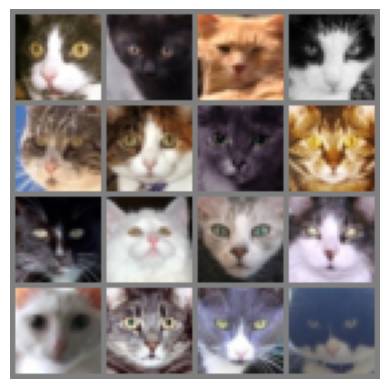

In [53]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [54]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [55]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 64), # 32 -> 16
            DownBlock(64, 128),                # 16 -> 8
            DownBlock(128, 256),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.down = nn.Sequential(
            sn(nn.Conv2d(in_channels, out_channels, 3, 2, 1)),
            # nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [56]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [57]:
def compute_gradient_penalty(real_images):
    B = real_images.size(0)

    std = real_images.std()
    perturbation = real_images + 0.5 * std * torch.randn_like(real_images)
    perturbation = perturbation.clamp(-1, 1)

    alpha = torch.rand(B, 1, 1, 1, device=device)

    interpolates = (alpha * real_images + (1 - alpha) * perturbation)
    interpolates.requires_grad_(True)

    d_interpolates = discriminator(interpolates)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates, device=device),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(B, -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

In [58]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [59]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.99))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.99))

In [60]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 0.7417  G_loss: 1.4209  D(x): 0.868  D(G(z)): -1.110:   4%|▍         | 199/5000 [00:19<07:22, 10.84it/s]

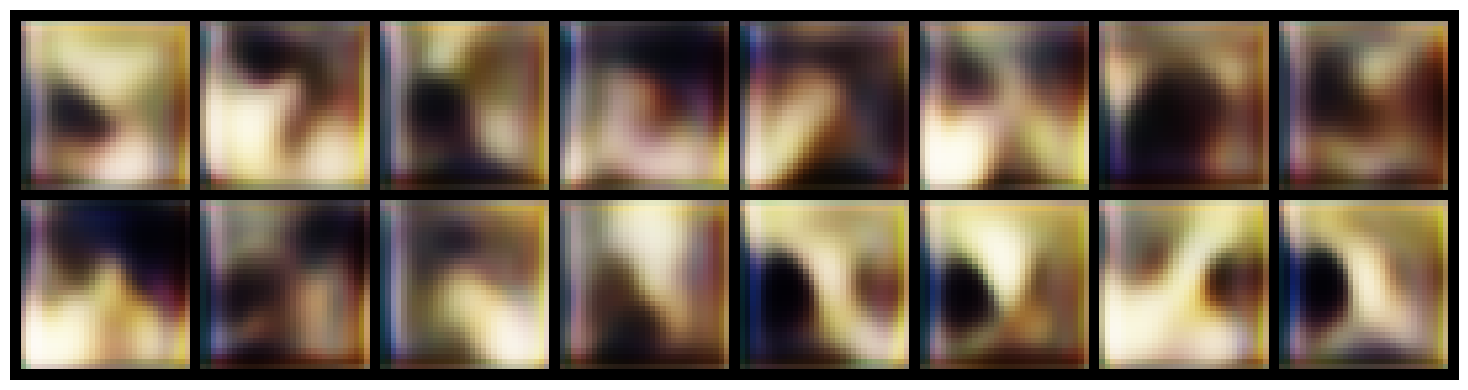

D_loss: 0.7833  G_loss: 1.3875  D(x): 1.137  D(G(z)): -1.071:   8%|▊         | 398/5000 [00:39<07:21, 10.42it/s]

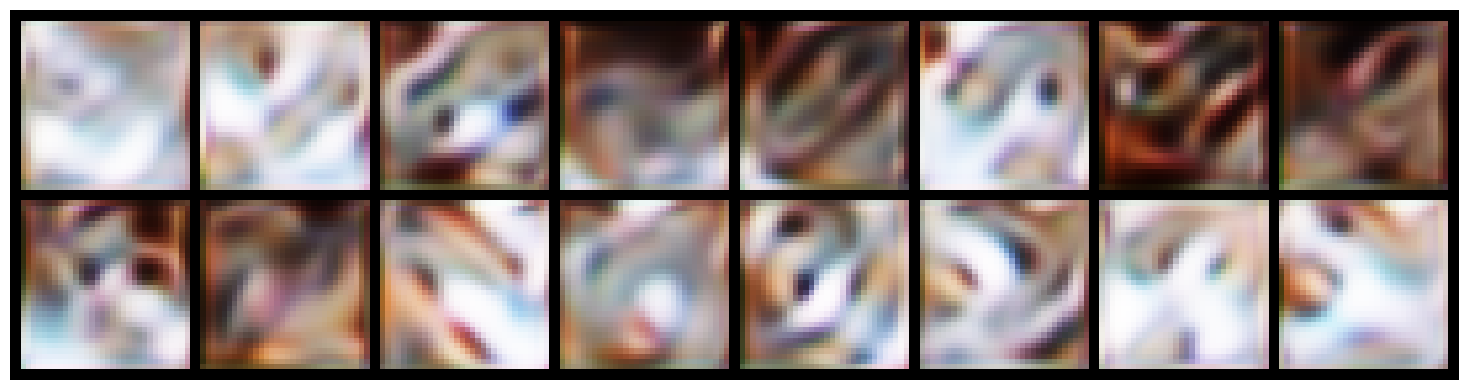

D_loss: 0.8424  G_loss: 1.1892  D(x): 0.701  D(G(z)): -0.783:  12%|█▏        | 598/5000 [00:58<06:35, 11.13it/s]

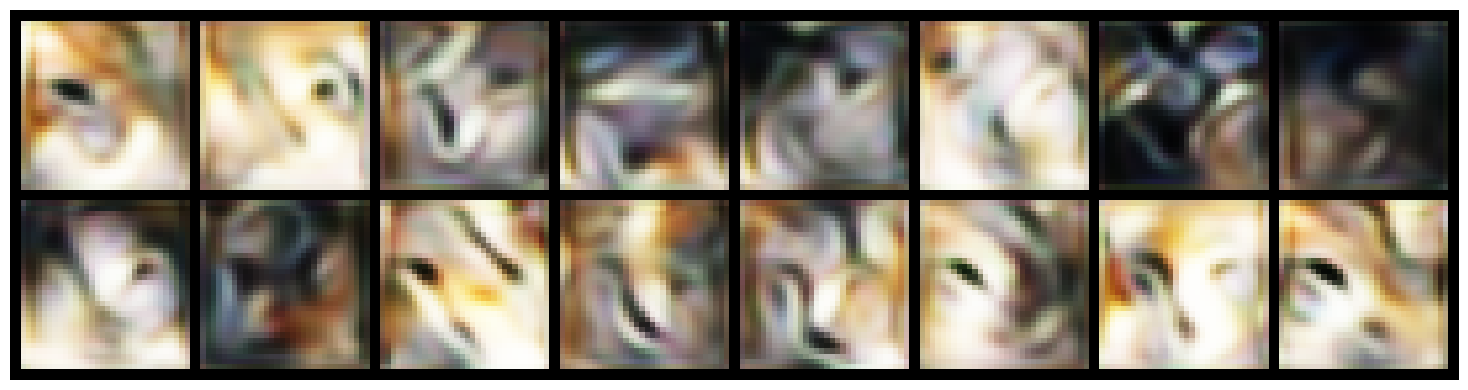

D_loss: 1.0743  G_loss: 1.1877  D(x): 0.002  D(G(z)): -0.770:  16%|█▌        | 799/5000 [01:18<08:40,  8.06it/s]

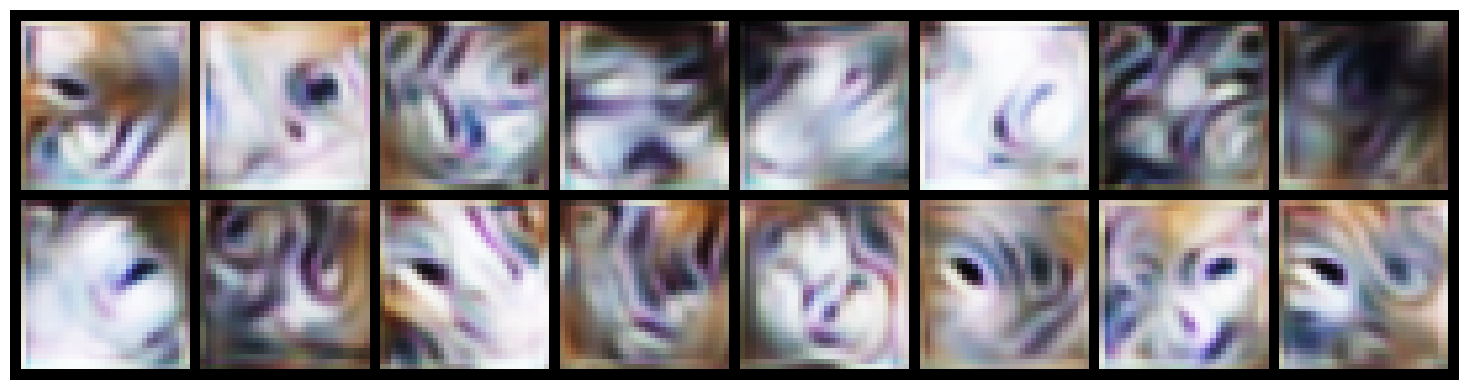

D_loss: 0.9086  G_loss: 1.1453  D(x): 0.822  D(G(z)): -0.735:  20%|█▉        | 999/5000 [01:37<05:58, 11.16it/s]

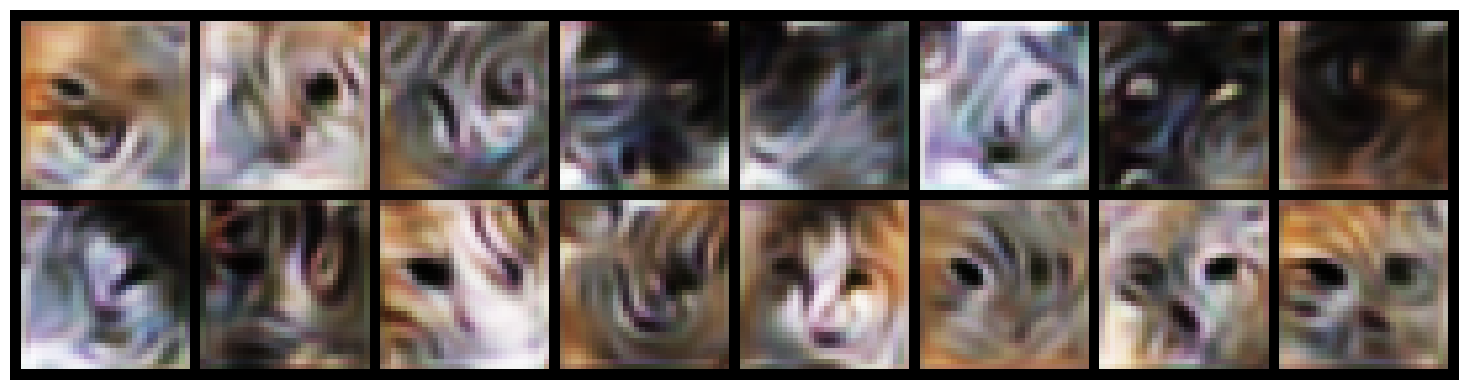

D_loss: 0.9738  G_loss: 1.0850  D(x): 0.514  D(G(z)): -0.636:  24%|██▍       | 1199/5000 [01:56<06:02, 10.48it/s]

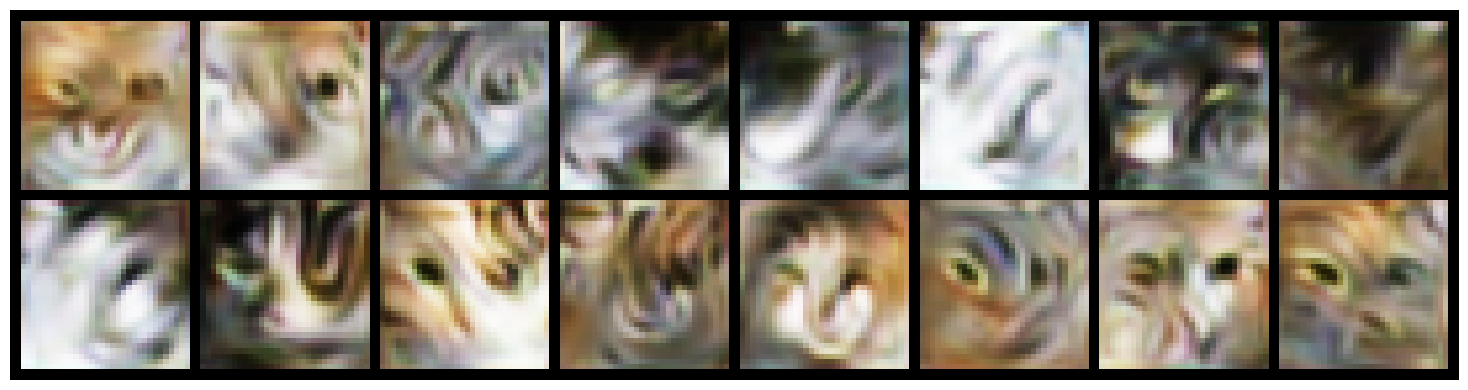

D_loss: 0.9608  G_loss: 0.9428  D(x): 0.485  D(G(z)): -0.428:  28%|██▊       | 1398/5000 [02:15<05:20, 11.25it/s]

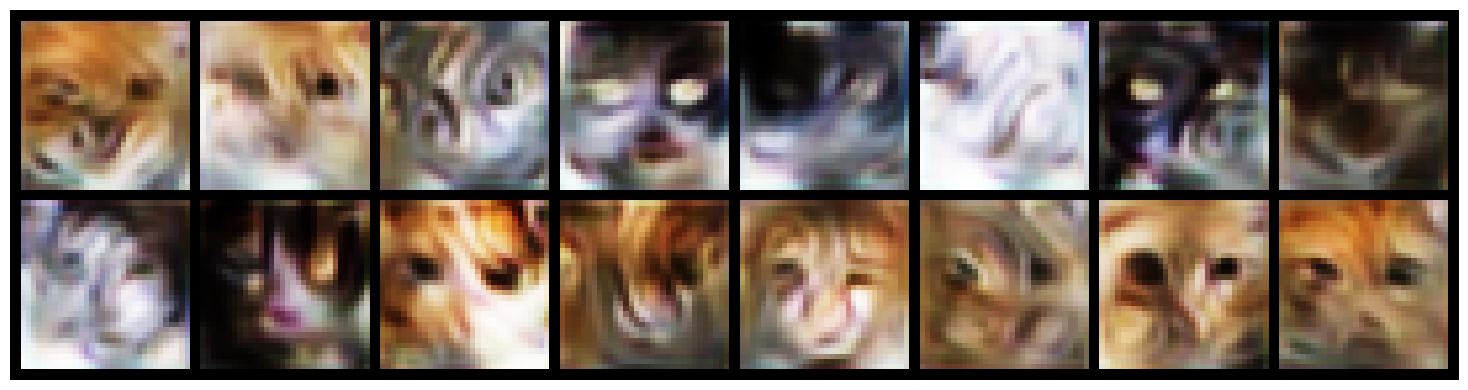

D_loss: 0.9573  G_loss: 1.0525  D(x): 0.600  D(G(z)): -0.612:  32%|███▏      | 1599/5000 [02:35<05:22, 10.54it/s]

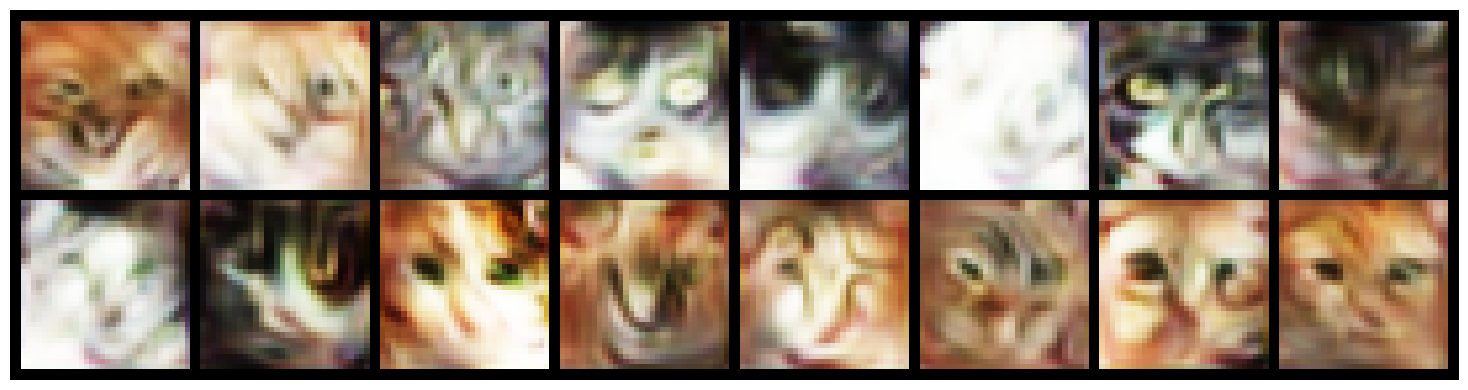

D_loss: 0.9671  G_loss: 1.0719  D(x): 0.620  D(G(z)): -0.621:  36%|███▌      | 1798/5000 [02:54<04:50, 11.03it/s]

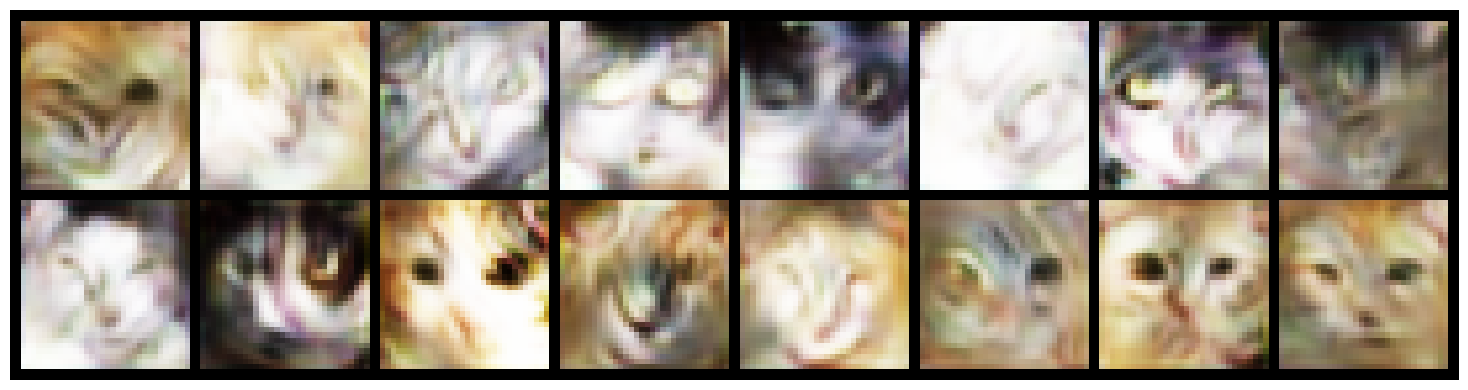

D_loss: 0.9470  G_loss: 0.9978  D(x): 0.330  D(G(z)): -0.514:  40%|███▉      | 1998/5000 [03:14<04:45, 10.51it/s]

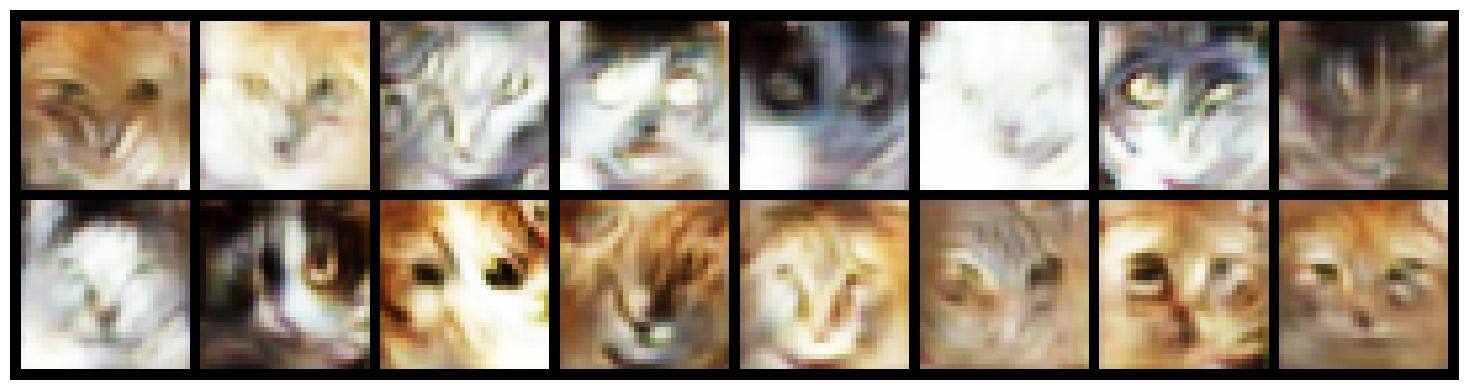

D_loss: 0.9772  G_loss: 1.0357  D(x): 0.513  D(G(z)): -0.575:  44%|████▍     | 2199/5000 [03:34<05:21,  8.71it/s]

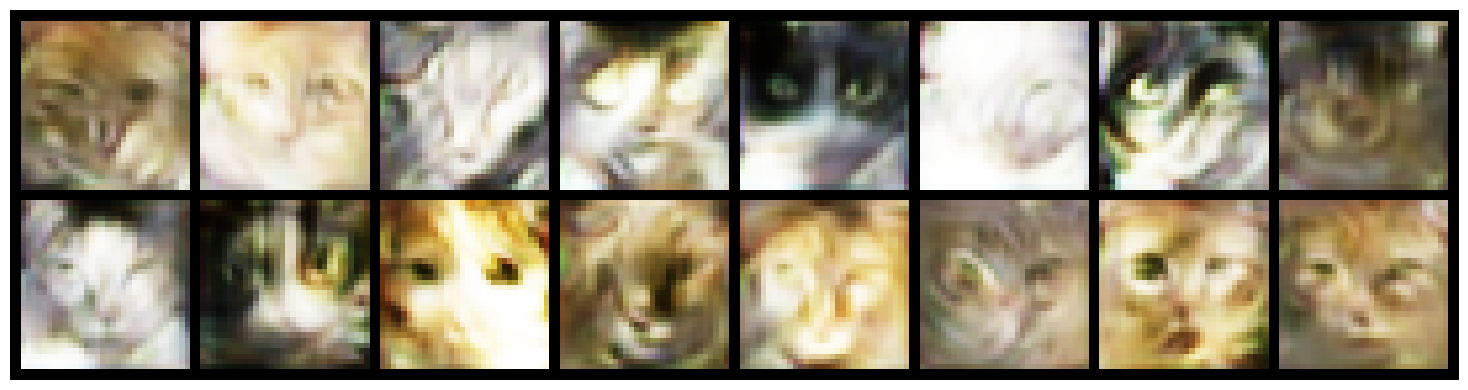

D_loss: 0.9747  G_loss: 0.9971  D(x): 0.477  D(G(z)): -0.505:  48%|████▊     | 2399/5000 [03:53<04:03, 10.69it/s]

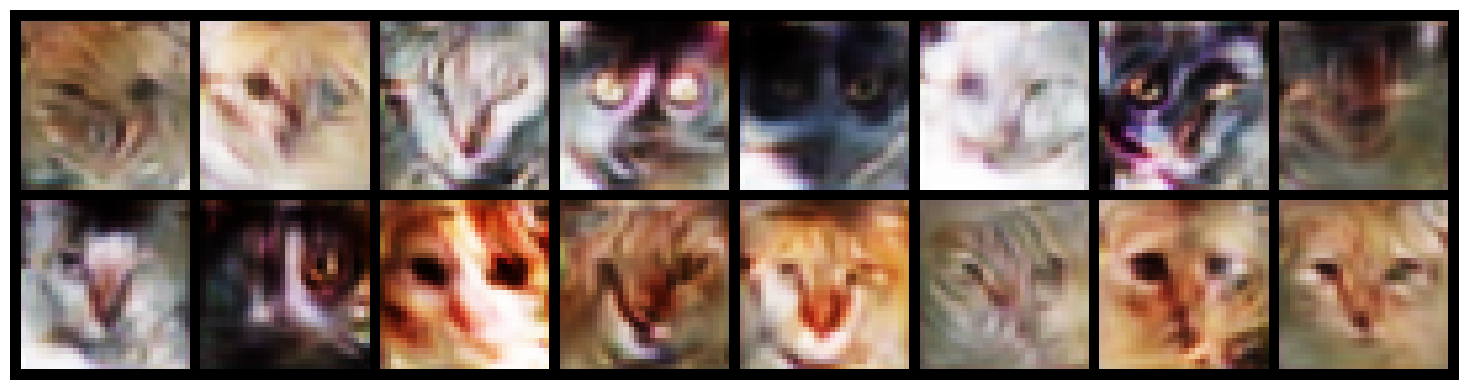

D_loss: 0.9943  G_loss: 1.0235  D(x): 0.417  D(G(z)): -0.559:  52%|█████▏    | 2598/5000 [04:13<03:47, 10.54it/s]

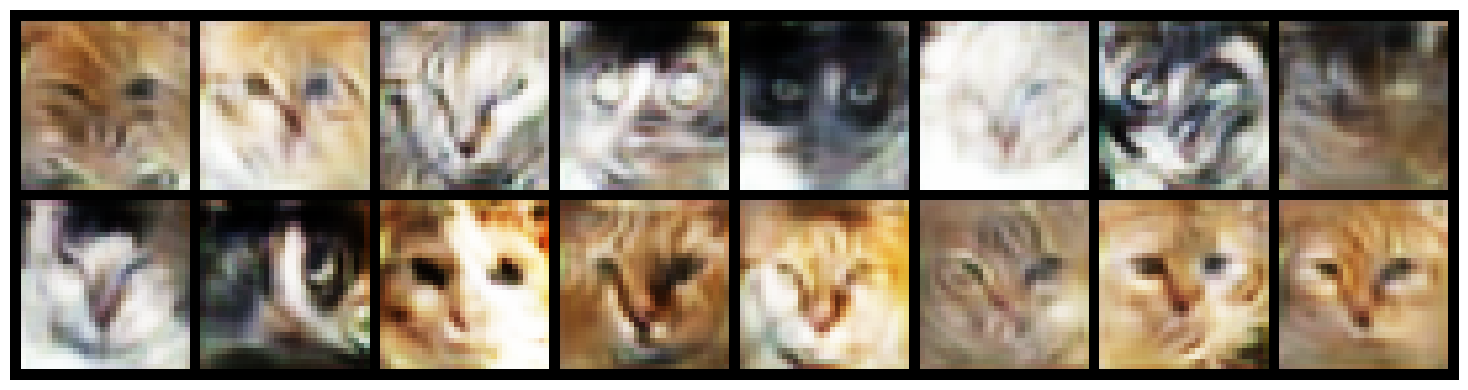

D_loss: 1.0242  G_loss: 0.9844  D(x): 0.399  D(G(z)): -0.496:  56%|█████▌    | 2799/5000 [04:33<03:19, 11.03it/s]

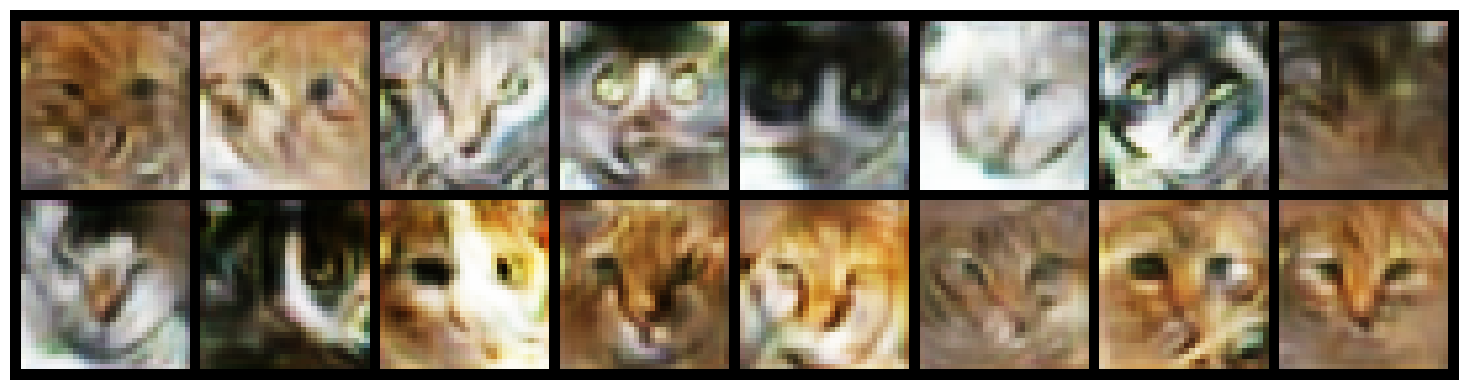

D_loss: 0.9806  G_loss: 1.0330  D(x): 0.389  D(G(z)): -0.573:  60%|█████▉    | 2998/5000 [04:53<03:03, 10.92it/s]

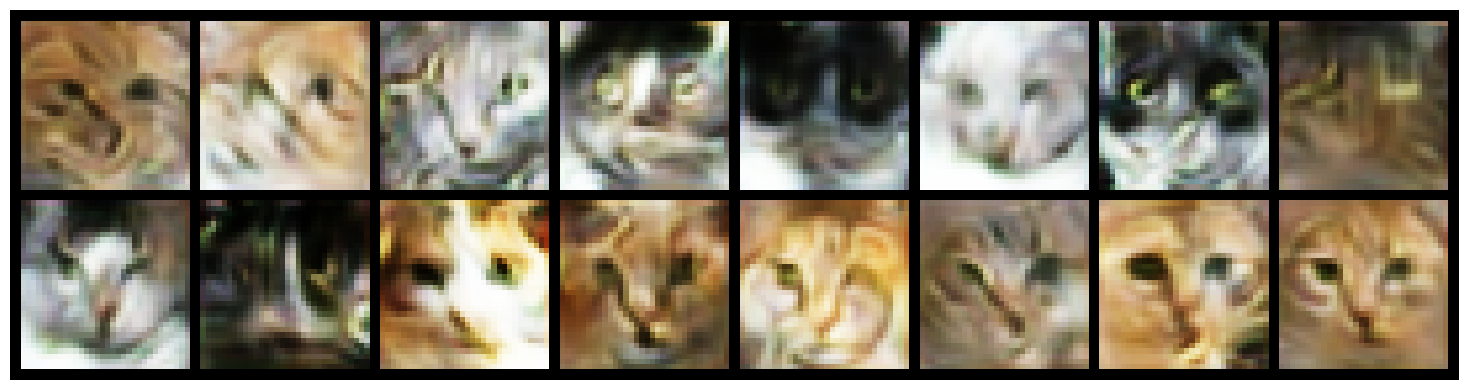

D_loss: 0.9989  G_loss: 0.9710  D(x): 0.432  D(G(z)): -0.479:  64%|██████▍   | 3198/5000 [05:12<02:45, 10.92it/s]

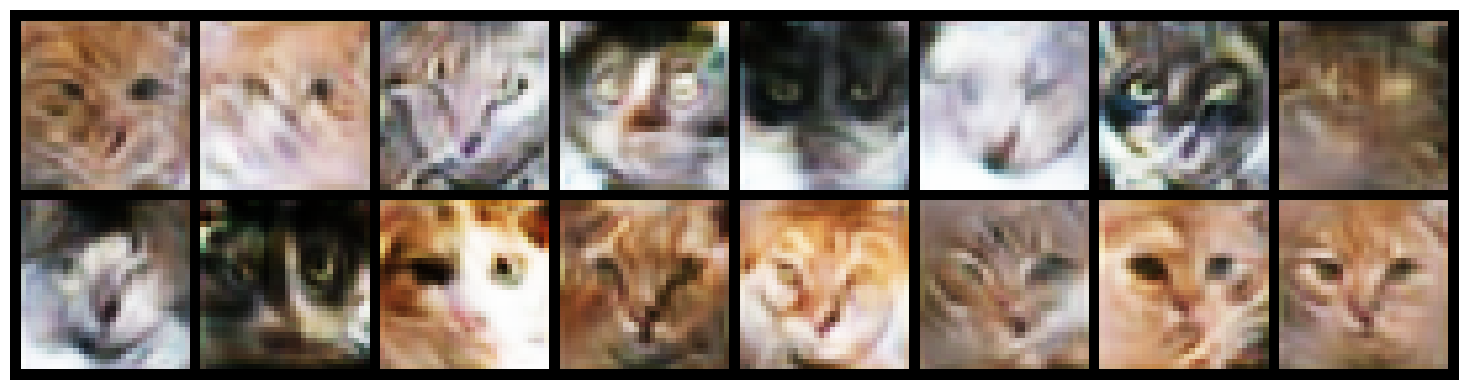

D_loss: 1.0128  G_loss: 0.9764  D(x): 0.480  D(G(z)): -0.487:  68%|██████▊   | 3399/5000 [05:34<03:02,  8.77it/s]

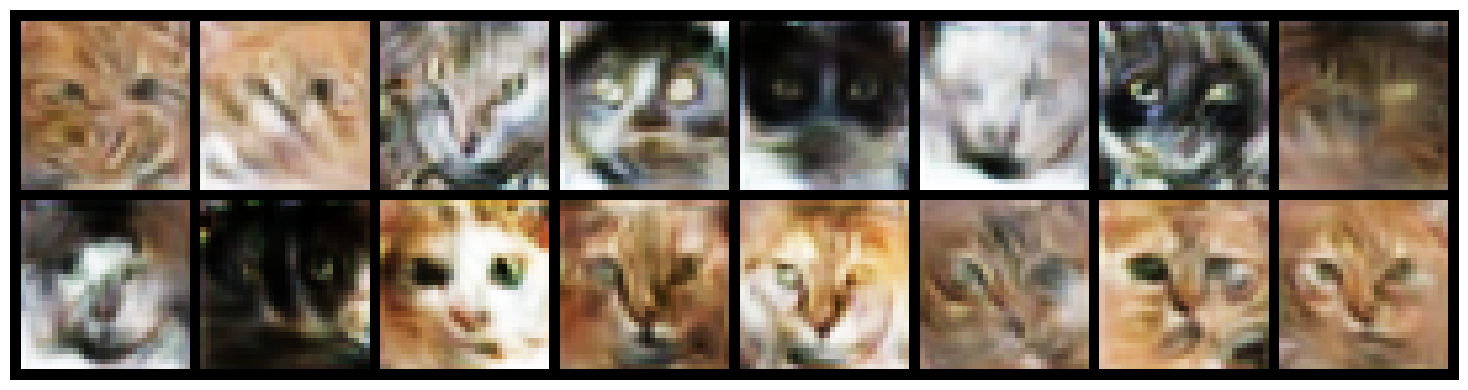

D_loss: 1.0042  G_loss: 1.1599  D(x): 0.692  D(G(z)): -0.760:  72%|███████▏  | 3599/5000 [05:54<02:14, 10.43it/s]

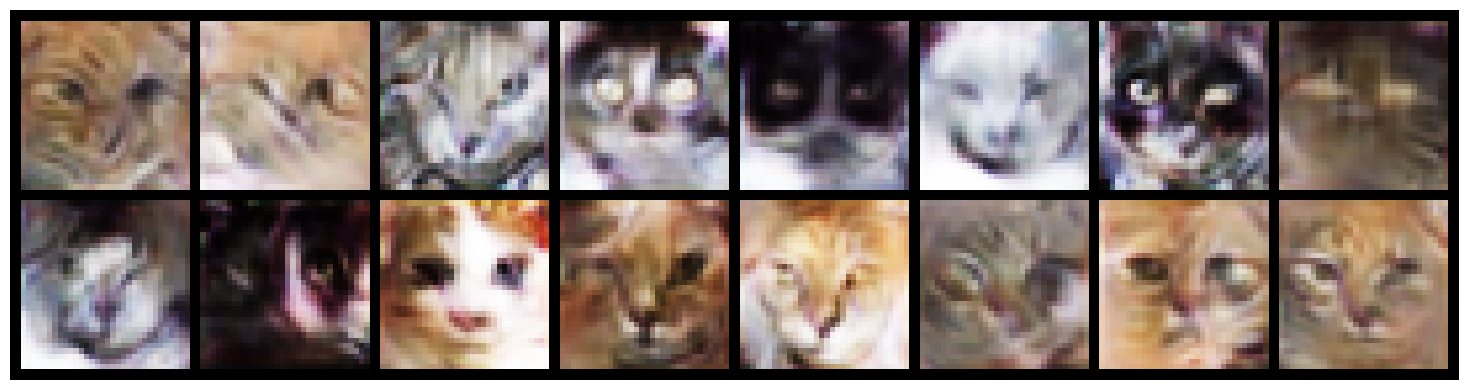

D_loss: 1.0256  G_loss: 1.1845  D(x): 0.560  D(G(z)): -0.804:  76%|███████▌  | 3799/5000 [06:14<01:50, 10.86it/s]

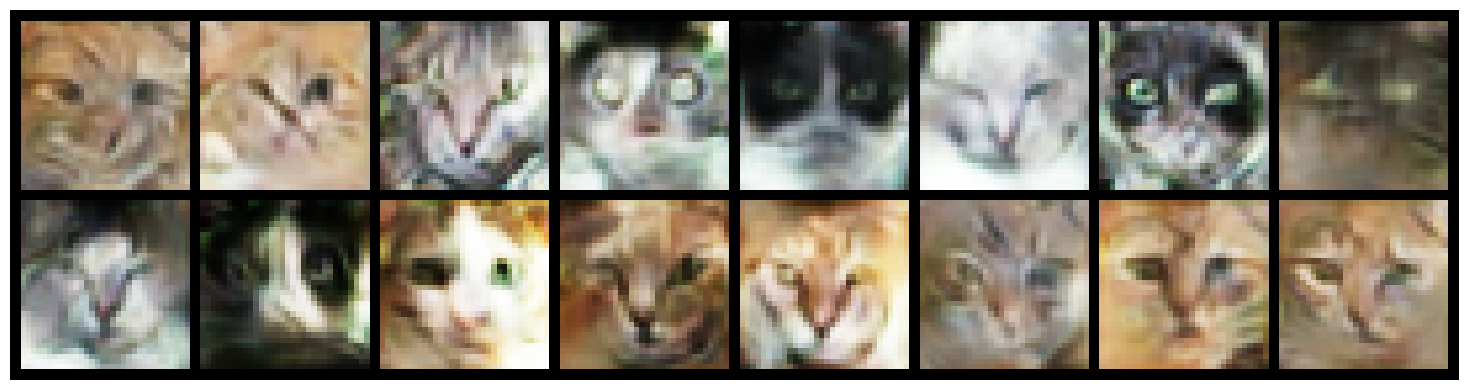

D_loss: 1.0540  G_loss: 1.0298  D(x): 0.610  D(G(z)): -0.565:  80%|███████▉  | 3999/5000 [06:34<01:31, 10.95it/s]

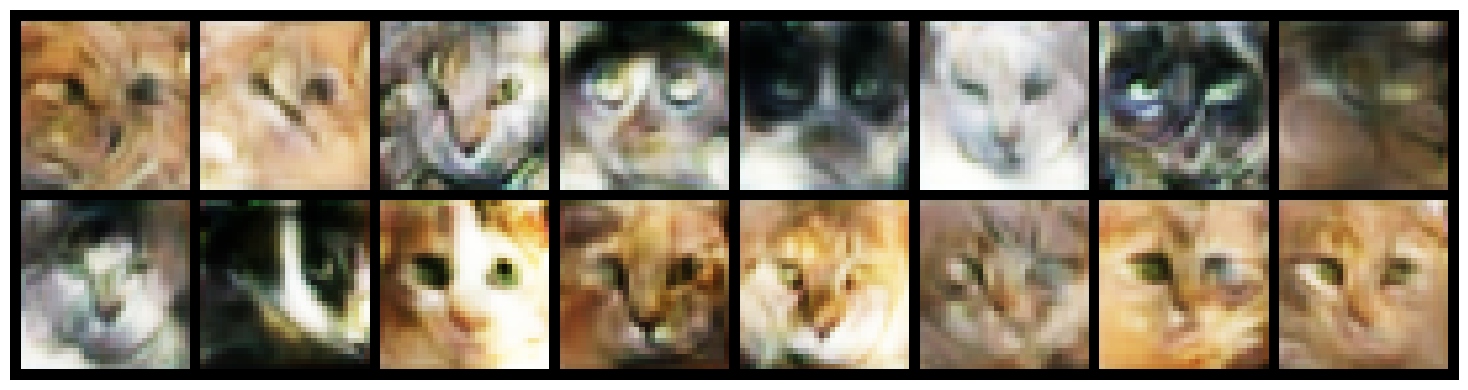

D_loss: 0.9716  G_loss: 1.0018  D(x): 0.589  D(G(z)): -0.523:  84%|████████▍ | 4199/5000 [06:54<01:33,  8.56it/s]

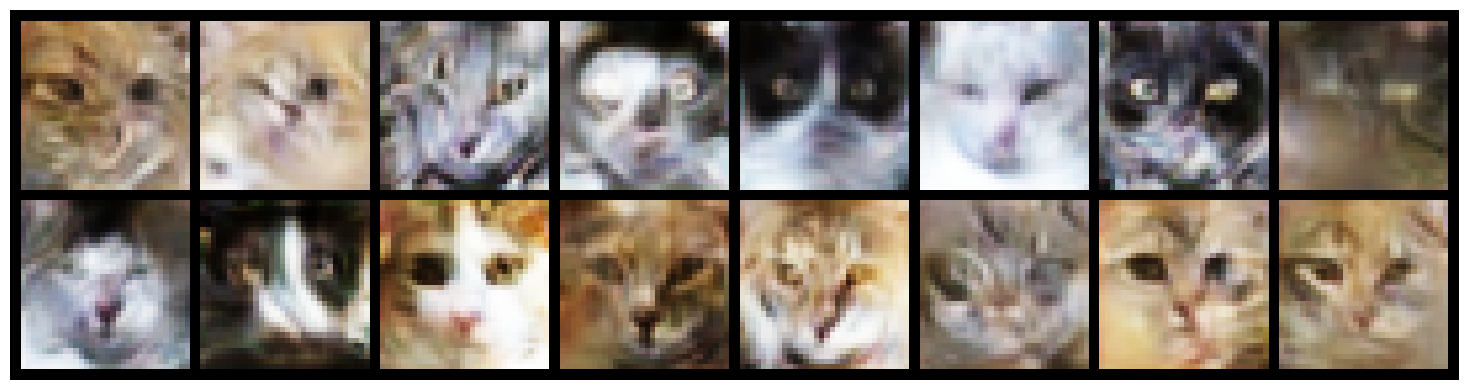

D_loss: 1.0835  G_loss: 1.0077  D(x): 0.350  D(G(z)): -0.540:  88%|████████▊ | 4399/5000 [07:14<00:54, 10.93it/s]

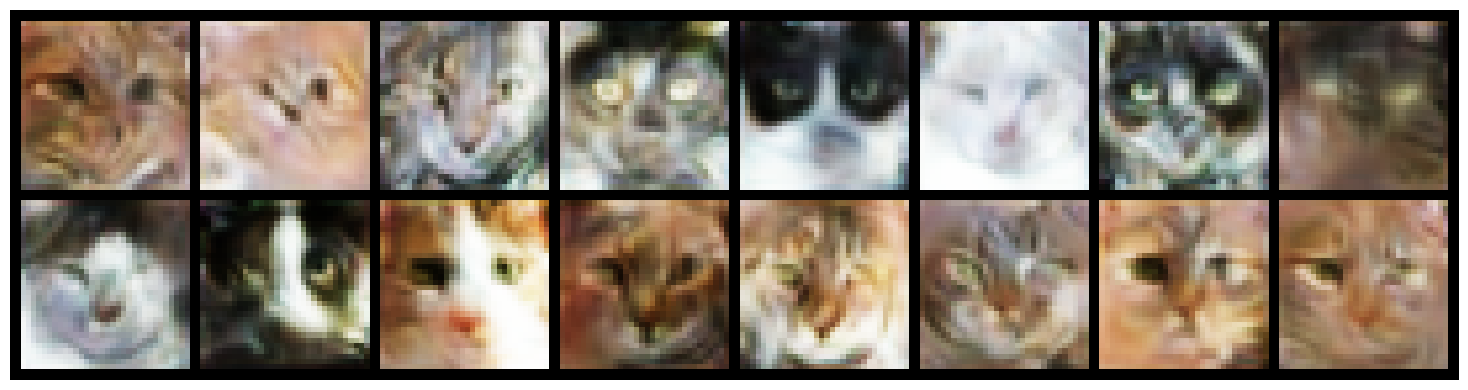

D_loss: 1.0615  G_loss: 0.9364  D(x): 0.290  D(G(z)): -0.422:  92%|█████████▏| 4599/5000 [07:35<00:40,  9.92it/s]

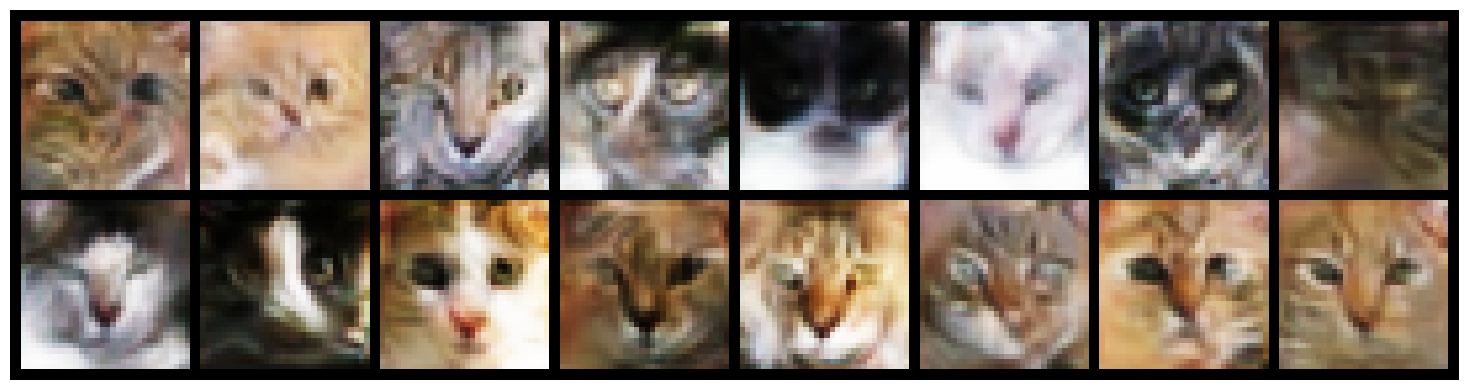

D_loss: 1.0522  G_loss: 0.9570  D(x): 0.511  D(G(z)): -0.456:  96%|█████████▌| 4799/5000 [07:55<00:20,  9.74it/s]

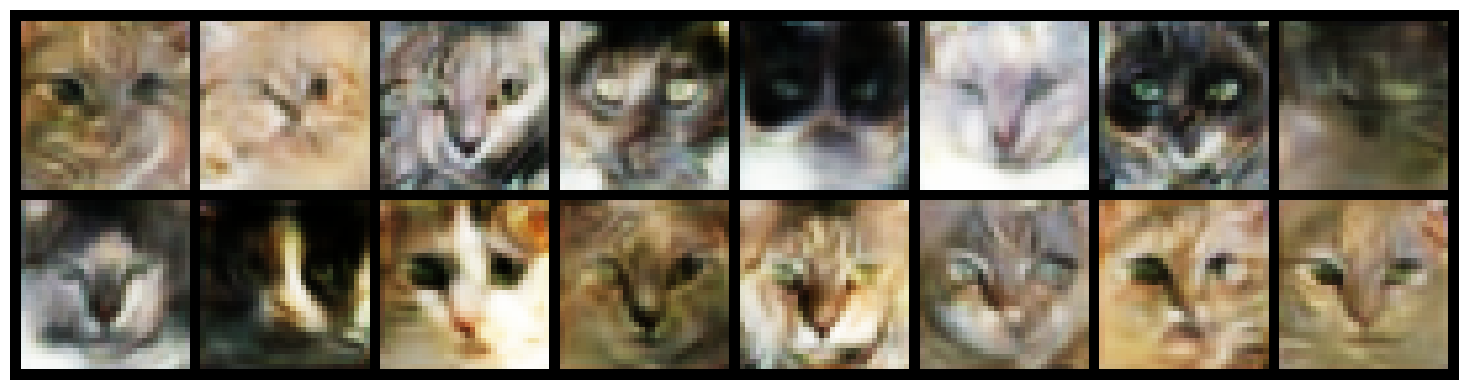

D_loss: 0.9611  G_loss: 1.0456  D(x): 0.456  D(G(z)): -0.595: 100%|█████████▉| 4999/5000 [08:18<00:00, 10.60it/s]

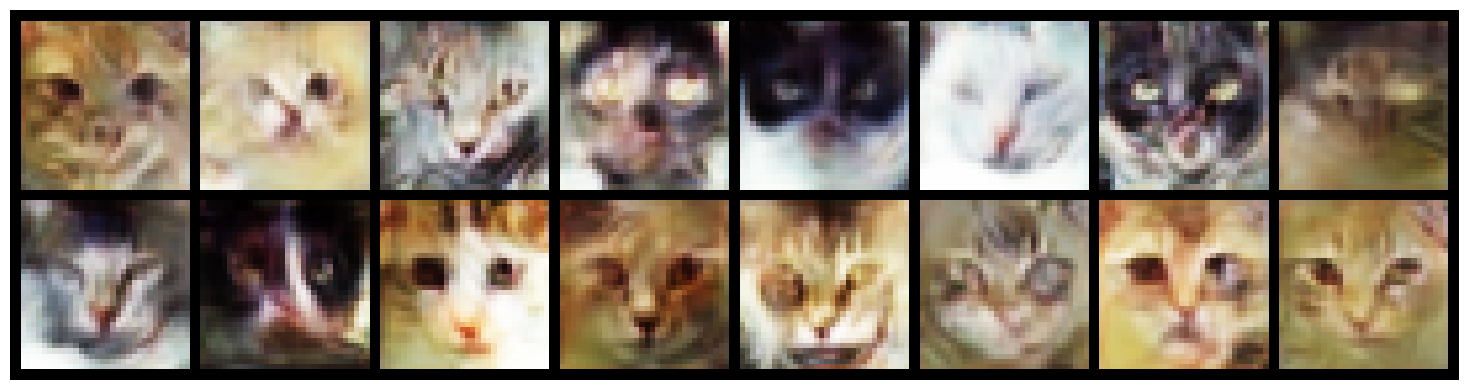

D_loss: 0.9611  G_loss: 1.0456  D(x): 0.456  D(G(z)): -0.595: 100%|██████████| 5000/5000 [08:18<00:00, 10.03it/s]


In [61]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="DRAGAN")

for step in pbar:
    real_images = next(train_loader).to(device)


    ########## D Train ##########
    for _ in range(2):
        z = torch.randn(batch_size, latent_size, device=device)
        with torch.no_grad():
            fake_images = generator(z)

        d_real = discriminator(real_images)
        d_fake = discriminator(fake_images)
        real_loss = criterion(d_real, real_targets)
        fake_loss = criterion(d_fake, fake_targets)

        gradient_penalty = compute_gradient_penalty(real_images)

        loss_D = real_loss + fake_loss + lambda_gp * gradient_penalty

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()


    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    loss_G = criterion(d_fake, real_targets)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)